# Datos y funciones de interpolación

Se dice que una función interpola a un conjunto de puntos si pasa a través de esos puntos. La función $y = P(x)$ interpola los puntos $(x_1,y_1),...,(x_n, y_n)$ si $P(x_i) = y_i$ para cada $1 \le i \le n$. Tener en cuenta que es necesario que $P$ sea una función.

# Interpolación de Lagrange

Suponga que se tiene n puntos de datos y que se desea encontrar un polinomio de interpolación. Existe una fórmula explícita, llamada fórmula de interpolación de Lagrange, para escribir un polinomio de grado $d = n - 1$ que interpola los puntos. Suponga que se tienen tres puntos. Entonces, el polinomio:

$$P_2(x)=y_1\frac{(x-x_2)(x-x_3)}{(x_1 - x_2)(x_1 - x_3)}+y_2\frac{(x - x_1)(x-x_3)}{(x_2 - x_1)(x_2 - x_3)} + y_3\frac{(x - x_1)(x - x_2)}{(x_3 - x_1)(x_3 - x_2)}$$

es el polinomio de interpolación de Lagrange que pasa por estos puntos.

Ejemplo: Encuentre el polinomio de interpolación de Lagrange para los puntos $(0,1), (2,2), (3,4)$.

$$P_2(x) = 1\frac{(x-2)(x-3)}{(0-2)(0-4)}+2\frac{(x-0)(x-3)}{(2-0)(2-3)} + 4\frac{(x - 0)(x-2)}{(3-0)(3-2)}$$

$$P_2(x)=\frac{1}{2}x^2 - \frac{1}{2}x + 1$$

En general, suponga que se tienen n puntos. Para cada k entre 1 y n, se define el polinomio de grado n-1:

$$L_k(x) = \frac{(x-x_1)...(x-x_{k-1})(x-x_{k+1})...(x-x_n)}{(x_k - x_1)...(x_k-x_{k-1})(x_k - x_{k+1})...(x_k - x_n)}$$

Donde $L_k(x_k) = 1$, mientras que $L_k(x_j) = 0$, donde $x_j$ es cualquiera de los otros puntos.

Entonces, se define el polinomio como:

$$P_{n-1}(x) = y_1L_1(x) + y_2L_2(x) + ... + y_nL_n(x)$$

O en una notación más compacta:

$$L_j(x) = \prod_{i=1, i \neq j}^n \frac{(x - x_i)}{(x_j - x_i)}$$

$$P_{n-1}(x) = \sum_{j = 1}^n y_jL_j(x)$$

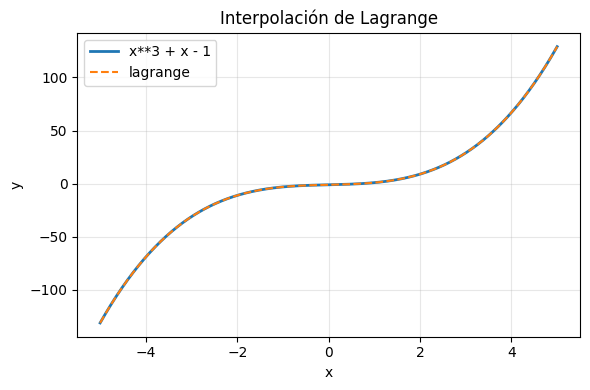

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def lagrange(x, px, py):

    n = px.shape[0]
    
    P = np.zeros(x.shape[0])

    for j in range(n):

        L = np.ones((x.shape[0]))

        for i in range(n):

            if i != j:
                L *= (x - px[i])/(px[j] - px[i])

            
        P += py[j]*L

    return P

def f(x):
    return x**3 + x - 1

px = np.array([-1, 0, 1, 2])
py = np.array([ -3,-1, 1, 9])

valores = np.linspace(-5,5,1000)
p = lagrange(valores, px, py)

fig, ax = plt.subplots(figsize = (6,4))
ax.plot(valores, f(valores), lw = 2, label = 'x**3 + x - 1')
ax.plot(valores, p, ls = '--' ,label = 'lagrange')
ax.set_title('Interpolación de Lagrange')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.grid(alpha = 0.3)
plt.tight_layout()
plt.show()
    
    